In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from torchvision.datasets import EuroSAT
from torchvision.transforms import ToTensor

from euroshap.utils.utils import report_filesize, shape_of_cutout
from euroshap.visualization.utils import plot_cutout
from euroshap.eda.eda import image_stats, outlier_report

First, let's verify the file size before we download

In [57]:
url = "http://madm.dfki.de/files/sentinel/EuroSAT.zip"  # URL for the dataset zip file
report_filesize(url)

File size in MB: 89.91295528411865


Let's inspect the labels

In [58]:
data = EuroSAT(root='../data/processed', transform=ToTensor(), download=True)

labels = data.classes
labels

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

There are 10 labels. Let's investigate the distribution of these labels in the dataset.

In [59]:
labels = [label for _, label in data]

label_counts = pd.Series(labels).value_counts()
label_counts

0    3000
1    3000
2    3000
7    3000
9    3000
3    2500
4    2500
6    2500
8    2500
5    2000
Name: count, dtype: int64

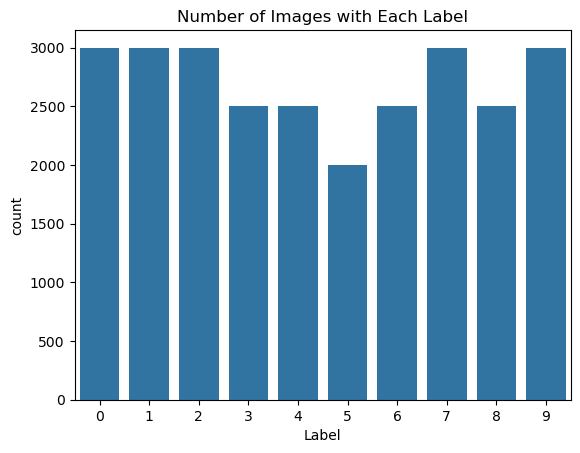

In [60]:
sns.barplot(data=label_counts)
plt.xlabel('Label')
plt.title('Number of Images with Each Label');

We have a relatively balanced distribution of labels by number. Next let's look at one image per label.

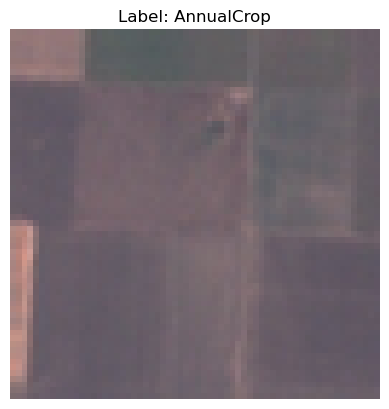

In [61]:
plot_cutout(data, 0)

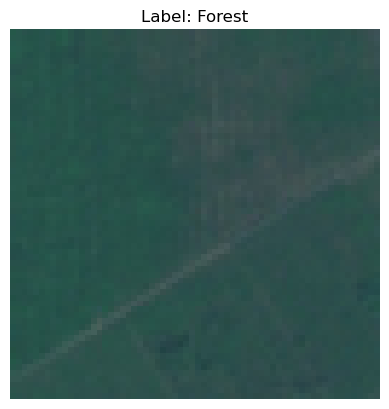

In [62]:
plot_cutout(data, 5_000)

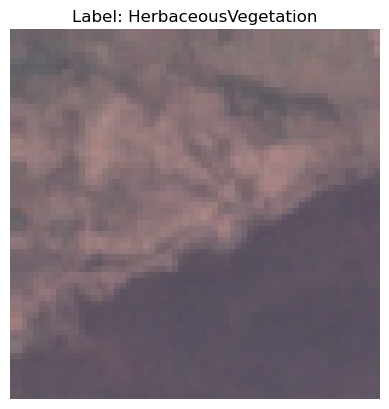

In [63]:
plot_cutout(data, 7_000)

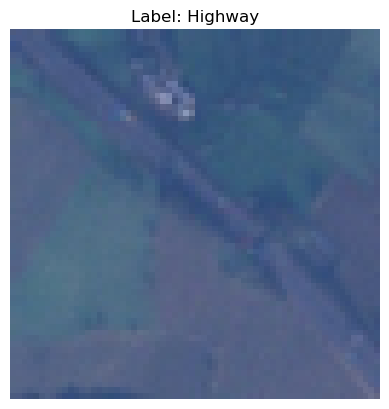

In [64]:
plot_cutout(data, 10_000)

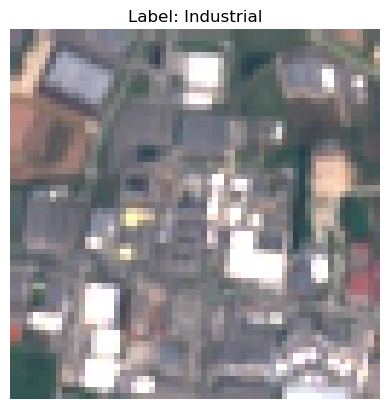

In [65]:
plot_cutout(data, 12_000)

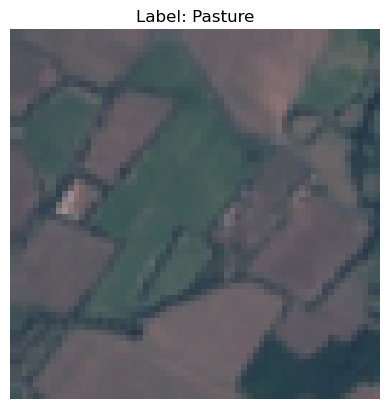

In [66]:
plot_cutout(data, 15_000)

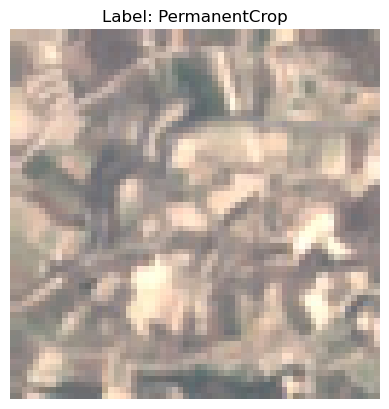

In [67]:
plot_cutout(data, 17_000)

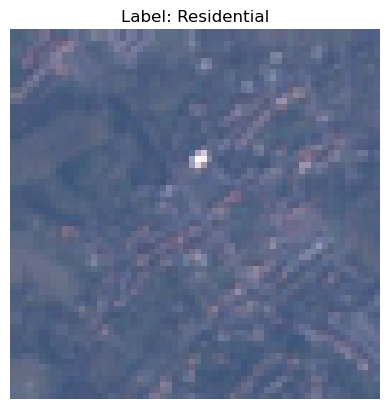

In [68]:
plot_cutout(data, 20_000)

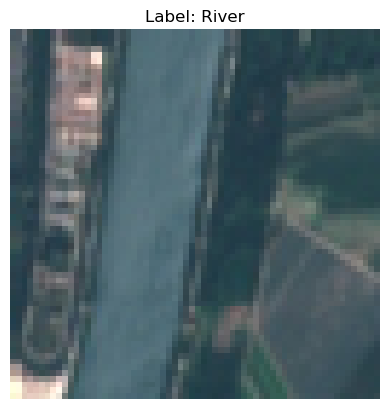

In [69]:
plot_cutout(data, 22_000)

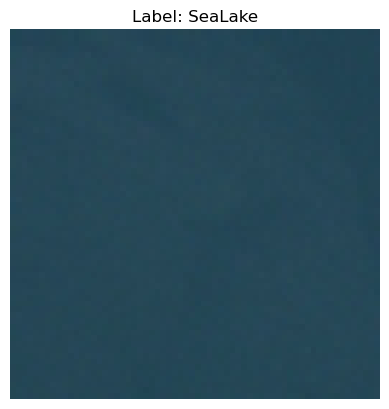

In [70]:
plot_cutout(data, 25_000)

In [71]:
shape_of_cutout(data)

Shape of images [color, height, width]: [3, 64, 64]


Next let's look at per channel statistics to identify any wildly different intensity ranges between images. First test the image_stats function.

In [72]:
df = image_stats(dataset=data, batch_size=256)
df

,mean_ch0,mean_ch1,mean_ch2,std_ch0,std_ch1,std_ch2
0,0.507045,0.468586,0.458070,0.236819,0.128722,0.102337
1,0.510950,0.470578,0.459478,0.229468,0.121807,0.097440
2,0.522528,0.478128,0.463328,0.239922,0.127776,0.101161
3,0.501643,0.467280,0.457977,0.235460,0.128320,0.102775
4,0.503601,0.467808,0.457225,0.236004,0.128052,0.102954
...,...,...,...,...,...,...
101,0.197907,0.297257,0.358445,0.105178,0.109880,0.072313
102,0.188013,0.283056,0.348460,0.102723,0.107172,0.070959
103,0.190220,0.285129,0.349336,0.099730,0.104907,0.068142
104,0.184691,0.283154,0.346851,0.097876,0.104889,0.069240


next run the report of images with outliers using a zscale threshold of 5

In [73]:
outlier_report(data, z_thresh=5)

{'mean_ch0': array([], dtype=int64),
 'mean_ch1': array([], dtype=int64),
 'mean_ch2': array([], dtype=int64)}